In [1]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import layers, Model

from ultralytics import YOLO

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = r"C:\Users\sujan\Desktop\final project2\DATASET\Processed_RiceDisease_Dataset\train"
val_dir = r"C:\Users\sujan\Desktop\final project2\DATASET\Processed_RiceDisease_Dataset\val"
test_dir = r"C:\Users\sujan\Desktop\final project2\DATASET\Processed_RiceDisease_Dataset\test"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1811 files belonging to 7 classes.


Found 362 files belonging to 7 classes.
Found 365 files belonging to 7 classes.


In [3]:
resnet_model = load_model("resnet50_final.keras")

print("ResNet50 loaded successfully!")

ResNet50 loaded successfully!


In [4]:
from ultralytics import YOLO

yolo_model = YOLO(
    r"C:\Users\sujan\Desktop\final project2\DATASET\runs\classify\runs\classify\RiceDisease_YOLO11-2\weights\best.pt"
)

print("YOLOv11 loaded successfully!")

YOLOv11 loaded successfully!


In [5]:
print("ResNet50 Model:")
resnet_model.summary()

print("\nYOLOv11 Model:")
print(yolo_model.model)

ResNet50 Model:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │      1,799 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,166,743 (96.00 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 1,052,688 (4.02 MB)


YOLOv11 Model:
ClassificationModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_runn

In [6]:
# View YOLOv11 classification architecture
print(yolo_model.model)

# Show each layer with its index
for i, layer in enumerate(yolo_model.model.model):
    print(f"{i}: {layer}")

ClassificationModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)


In [7]:
from tensorflow.keras.models import Model

# Load your trained ResNet50 model
resnet_model = load_model("resnet50_final.keras")

# Remove the last Softmax layer
resnet_feature_extractor = Model(
    inputs=resnet_model.input,
    outputs=resnet_model.layers[-2].output
)

print("ResNet50 Feature Extractor Ready!")
print("Feature Shape:", resnet_feature_extractor.output_shape)

ResNet50 Feature Extractor Ready!
Feature Shape: (None, 256)


In [8]:
# Get one batch
images, labels = next(iter(train_ds))

# Extract ResNet features
resnet_features = resnet_feature_extractor.predict(images)

print("Images Shape :", images.shape)
print("ResNet Features Shape :", resnet_features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Images Shape : (32, 224, 224, 3)
ResNet Features Shape : (32, 256)


In [9]:
import torch
import numpy as np

# Put YOLO model in evaluation mode
yolo_model.model.eval()

# Remove the final Linear layer (7-class classifier)
yolo_feature_extractor = torch.nn.Sequential(
    *list(yolo_model.model.model.children())[:-1]
)

print("YOLO Feature Extractor Ready!")

YOLO Feature Extractor Ready!


In [10]:
import torch

# Convert TensorFlow images to PyTorch format
images_torch = torch.tensor(images.numpy()).permute(0, 3, 1, 2).float()

with torch.no_grad():
    yolo_features = yolo_feature_extractor(images_torch)

print("YOLO Features Shape:", yolo_features.shape)

YOLO Features Shape: torch.Size([32, 256, 7, 7])


In [11]:
import torch.nn as nn

# Global Average Pooling
gap = nn.AdaptiveAvgPool2d((1, 1))

# Apply pooling
yolo_features = gap(yolo_features)

# Flatten to a vector
yolo_features = yolo_features.view(yolo_features.size(0), -1)

print("YOLO Features Shape:", yolo_features.shape)

YOLO Features Shape: torch.Size([32, 256])


In [12]:
import torch
import numpy as np

def extract_features(dataset):

    X = []
    y = []

    for images, labels in dataset:

        # -----------------------------
        # ResNet50 Features
        # -----------------------------
        res_features = resnet_feature_extractor.predict(images, verbose=0)

        # -----------------------------
        # YOLO Features
        # -----------------------------
        images_torch = torch.tensor(images.numpy()).permute(0,3,1,2).float()

        with torch.no_grad():
            yolo_feat = yolo_feature_extractor(images_torch)

            yolo_feat = gap(yolo_feat)
            yolo_feat = yolo_feat.view(yolo_feat.size(0), -1)
            yolo_feat = yolo_feat.numpy()

        # -----------------------------
        # Feature Fusion
        # -----------------------------
        fused = np.concatenate([res_features, yolo_feat], axis=1)

        X.append(fused)
        y.append(labels.numpy())

    X = np.vstack(X)
    y = np.concatenate(y)

    return X, y

In [13]:
print("Extracting Train Features...")
X_train, y_train = extract_features(train_ds)

print("Extracting Validation Features...")
X_val, y_val = extract_features(val_ds)

print("Extracting Test Features...")
X_test, y_test = extract_features(test_ds)

print("Done!")

Extracting Train Features...
Extracting Validation Features...
Extracting Test Features...
Done!


In [14]:
print("Train :", X_train.shape)
print("Val   :", X_val.shape)
print("Test  :", X_test.shape)

Train : (1811, 512)
Val   : (362, 512)
Test  : (365, 512)


In [15]:
print(len(train_ds.file_paths))
print(len(val_ds.file_paths))
print(len(test_ds.file_paths))

1811
362
365


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

hybrid_model = Sequential([

    Dense(512, activation='relu', input_shape=(512,)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(7, activation='softmax')

])

hybrid_model.summary()

C:\Users\sujan\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 430,855 (1.64 MB)

 Trainable params: 429,319 (1.64 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [17]:
from tensorflow.keras.optimizers import Adam

hybrid_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Hybrid Model Compiled Successfully!")

Hybrid Model Compiled Successfully!


In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        verbose=1
    )

]

In [19]:
history = hybrid_model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=15,

    batch_size=32,

    callbacks=callbacks

)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5687 - loss: 1.2785 - val_accuracy: 0.3343 - val_loss: 3.8175 - learning_rate: 0.0010
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7880 - loss: 0.6192 - val_accuracy: 0.5691 - val_loss: 1.4376 - learning_rate: 0.0010
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8454 - loss: 0.4323 - val_accuracy: 0.7044 - val_loss: 0.9259 - learning_rate: 0.0010
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8874 - loss: 0.3257 - val_accuracy: 0.6934 - val_loss: 0.8213 - learning_rate: 0.0010
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8851 - loss: 0.3122 - val_accuracy: 0.6492 - val_loss: 0.9714 - learning_rate: 0.0010
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8857 - loss: 0.3216 - val_accuracy: 0.5497 - val_loss: 1.4593 - learning_rate: 0.0010
Epoch 7/15
54/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8869 - loss: 0.3245
Epoch 7: Reduce

In [20]:
test_loss, test_accuracy = hybrid_model.evaluate(X_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6493 - loss: 0.9563 
Test Loss : 0.9562525153160095
Test Accuracy : 0.6493150591850281


In [21]:
class_names = [
    "bacterial_leaf_blight",
    "brown_spot",
    "healthy",
    "leaf_blast",
    "leaf_scald",
    "leaf_smut",
    "narrow_brown_spot"
]

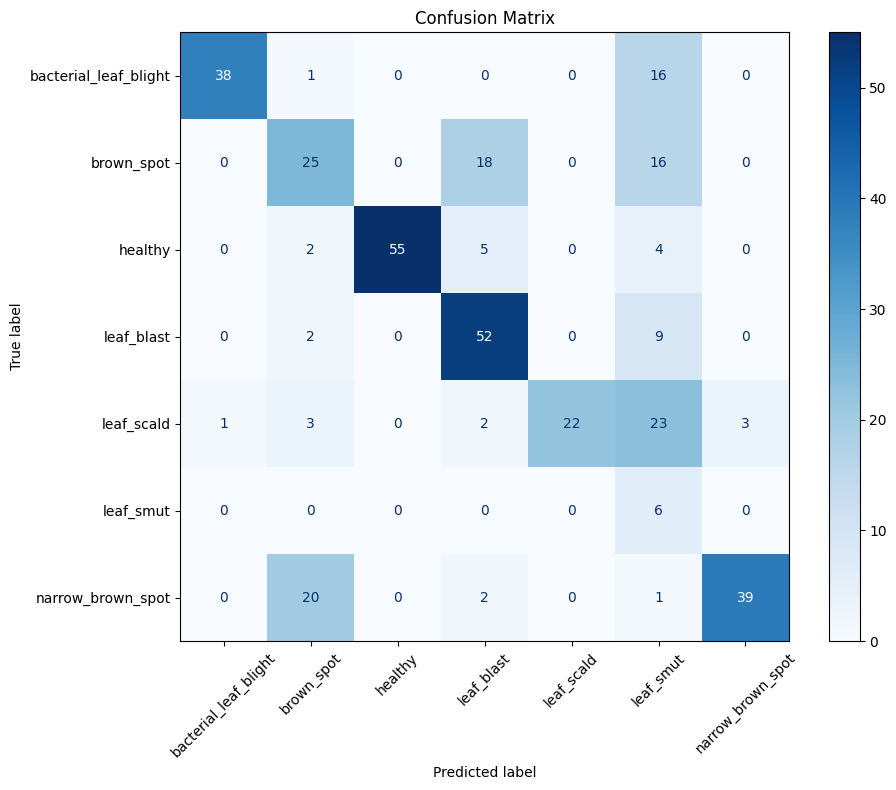

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = hybrid_model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.97      0.69      0.81        55
           brown_spot       0.47      0.42      0.45        59
              healthy       1.00      0.83      0.91        66
           leaf_blast       0.66      0.83      0.73        63
           leaf_scald       1.00      0.41      0.58        54
            leaf_smut       0.08      1.00      0.15         6
    narrow_brown_spot       0.93      0.63      0.75        62

             accuracy                           0.65       365
            macro avg       0.73      0.69      0.62       365
         weighted avg       0.82      0.65      0.70       365



In [25]:
hybrid_model.save("Hybrid_ResNet50_YOLOv11.keras")

print("Hybrid model saved successfully!")

Hybrid model saved successfully!
